# Data Cleaning

In [1]:
import pandas as pd

In [2]:
per_game = pd.read_csv("Player Per Game.csv")
advanced = pd.read_csv("Advanced.csv")
all_star = pd.read_csv("All-Star Selections.csv")

In [3]:
per_game.columns = per_game.columns.str.strip().str.lower()
advanced.columns = advanced.columns.str.strip().str.lower()
all_star.columns = all_star.columns.str.strip().str.lower()

In [4]:
df = pd.merge(
    per_game,
    advanced,
    on=["player_id", "season"],
    how="inner",
    suffixes=("_pg", "_adv")
)

all_star["allstar"] = 1

all_star_labels = all_star[["player_id", "season", "allstar"]].drop_duplicates()

df = pd.merge(
    df,
    all_star_labels,
    on=["player_id", "season"],
    how="left"
)

df["allstar"] = df["allstar"].fillna(0).astype(int)

In [5]:
print("===== DATASET STATISTICS =====\n")

print(f"Number of records: {df.shape[0]}")
print(f"Number of columns (including target): {df.shape[1]}")

print("\nFeature types:")
print(df.dtypes.value_counts())

print("\nMissing values by column (top 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nClass distribution:")
print(df["allstar"].value_counts())

print("\nClass distribution (%):")
print((df["allstar"].value_counts(normalize=True) * 100).round(2))

print("\nColumns:")
print(df.columns.tolist())

===== DATASET STATISTICS =====

Number of records: 52984
Number of columns (including target): 61

Feature types:
float64    48
object      9
int64       4
Name: count, dtype: int64

Missing values by column (top 15):
x3p_percent      17527
gs_pg            13118
gs_adv           13067
x2p_percent      10432
x3p_ar           10251
e_fg_percent     10250
x3pa_per_game     9959
x2pa_per_game     9958
x2p_per_game      9958
x3p_per_game      9958
dbpm              9211
obpm              9211
bpm               9211
vorp              9201
stl_percent       9154
dtype: int64

Class distribution:
allstar
0    50526
1     2458
Name: count, dtype: int64

Class distribution (%):
allstar
0    95.36
1     4.64
Name: proportion, dtype: float64

Columns:
['season', 'lg_pg', 'player_pg', 'player_id', 'age_pg', 'team_pg', 'pos_pg', 'g_pg', 'gs_pg', 'mp_per_game', 'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game', 'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game', 'x2p_percent',

# Exploratory Data Analysis

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

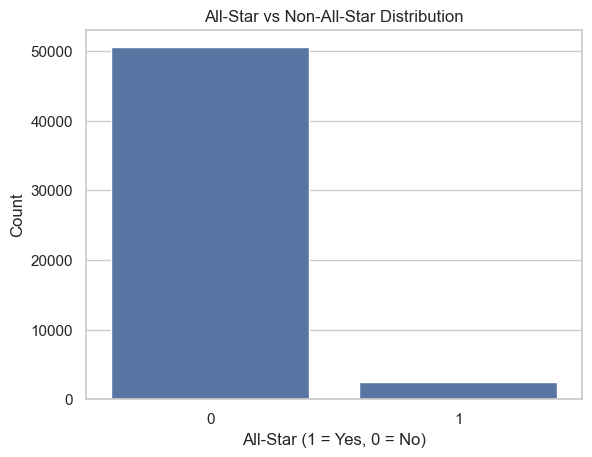

In [7]:
sns.countplot(x="allstar", data=df)
plt.title("All-Star vs Non-All-Star Distribution")
plt.xlabel("All-Star (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

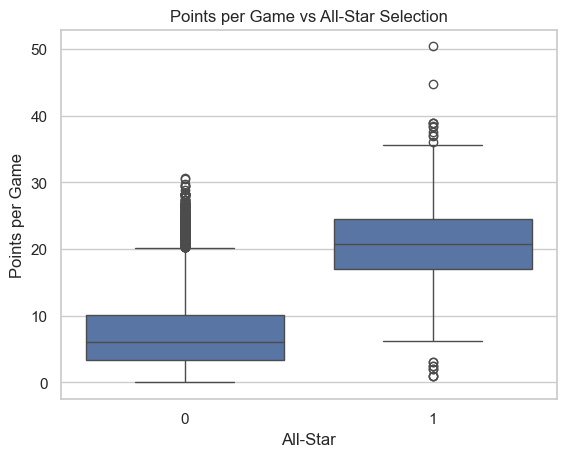

In [8]:
sns.boxplot(x="allstar", y="pts_per_game", data=df)
plt.title("Points per Game vs All-Star Selection")
plt.xlabel("All-Star")
plt.ylabel("Points per Game")
plt.show()

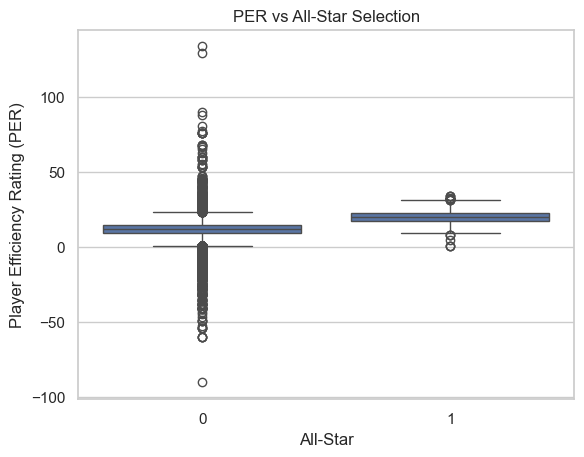

In [9]:
sns.boxplot(x="allstar", y="per", data=df)
plt.title("PER vs All-Star Selection")
plt.xlabel("All-Star")
plt.ylabel("Player Efficiency Rating (PER)")
plt.show()

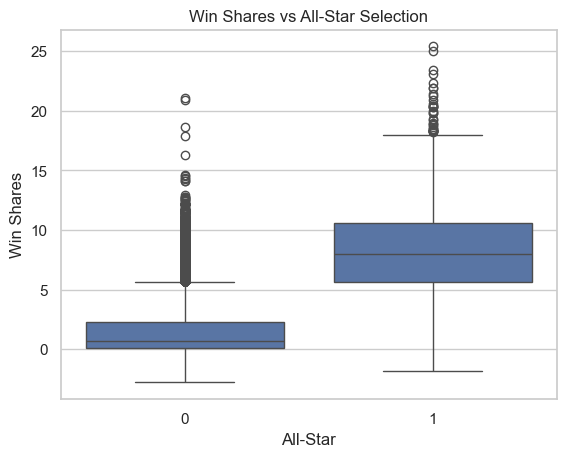

In [10]:
sns.boxplot(x="allstar", y="ws", data=df)
plt.title("Win Shares vs All-Star Selection")
plt.xlabel("All-Star")
plt.ylabel("Win Shares")
plt.show()

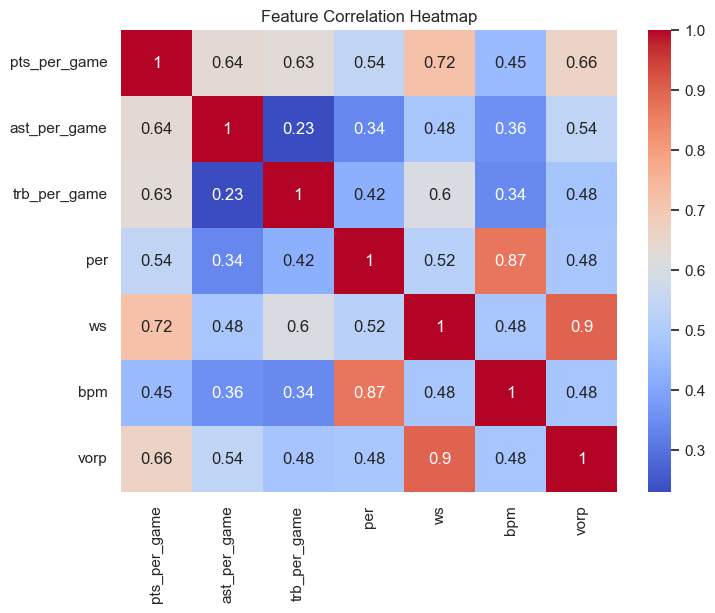

In [11]:
features = ["pts_per_game", "ast_per_game", "trb_per_game", "per", "ws", "bpm", "vorp"]

corr = df[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

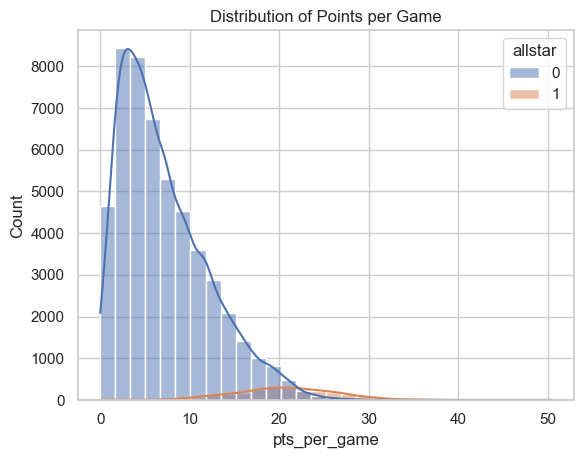

In [12]:
sns.histplot(data=df, x="pts_per_game", hue="allstar", bins=30, kde=True)
plt.title("Distribution of Points per Game")
plt.show()

## Feature Selection & Filtering

We apply filters to produce a clean modeling dataset:
- **Modern era only (1980+):** Advanced metrics are very sparse before 1980.
- **Minimum 20 games played:** Removes players with tiny sample sizes who would never realistically be All-Star candidates.
- **Drop identifier/duplicate columns:** Keep only numeric performance features.
- **Fill remaining NaNs with 0:** Primarily `x3p_percent` for players who never attempted a three-pointer, `ft_percent` for 0 FTA, etc.

In [ ]:
# filter to modern era, minimum games
df = df[(df["season"] >= 1980) & (df["g_pg"] >= 20)].copy()
print(f"After filtering: {df.shape[0]} rows")
print(f"\nClass distribution:")
print(df["allstar"].value_counts())
print(f"\nAll-Star rate: {df['allstar'].mean()*100:.2f}%")

After filtering: 29093 rows

Class distribution:
allstar
0    27779
1     1314
Name: count, dtype: int64

All-Star rate: 4.52%


In [ ]:
# drop non-feature columns
drop_cols = [
    "season", "lg_pg", "player_pg", "player_id", "team_pg", "pos_pg",
    "lg_adv", "player_adv", "team_adv", "pos_adv",
    "age_adv", "g_adv", "gs_adv", "gs_pg",  # duplicates from merge
    "allstar"
]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy().fillna(0)
y = df["allstar"].copy()

print(f"Number of features: {len(feature_cols)}")
print(f"Features:\n{feature_cols}")
print(f"\nX shape: {X.shape}")
print(f"Any NaNs remaining: {X.isnull().any().any()}")

Number of features: 46
Features:
['age_pg', 'g_pg', 'mp_per_game', 'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game', 'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game', 'x2p_percent', 'e_fg_percent', 'ft_per_game', 'fta_per_game', 'ft_percent', 'orb_per_game', 'drb_per_game', 'trb_per_game', 'ast_per_game', 'stl_per_game', 'blk_per_game', 'tov_per_game', 'pf_per_game', 'pts_per_game', 'mp', 'per', 'ts_percent', 'x3p_ar', 'f_tr', 'orb_percent', 'drb_percent', 'trb_percent', 'ast_percent', 'stl_percent', 'blk_percent', 'tov_percent', 'usg_percent', 'ows', 'dws', 'ws', 'ws_48', 'obpm', 'dbpm', 'bpm', 'vorp']

X shape: (29093, 46)
Any NaNs remaining: False


## Model Training & Evaluation

We train five classification models:

1. **Logistic Regression** — discriminative baseline
2. **Regularized Logistic Regression (L1 / Lasso)** — automatic feature selection via sparsity
3. **Gaussian Naive Bayes** — generative baseline assuming feature independence
4. **Linear Discriminant Analysis (LDA)** — generative model with shared covariance
5. **Quadratic Discriminant Analysis (QDA)** — generative model with per-class covariance

This allows us to compare discriminative vs. generative approaches and linear vs. quadratic decision boundaries.

### Train/Test Split & Standardization

We use an 80/20 stratified split to preserve the class imbalance ratio in both sets, then standardize features using training set statistics only (to avoid data leakage).

In [17]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, f1_score, precision_score, recall_score,
    accuracy_score, roc_auc_score
)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples ({y_train.mean()*100:.2f}% All-Star)")
print(f"Test:  {X_test.shape[0]} samples ({y_test.mean()*100:.2f}% All-Star)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: 23274 samples (4.52% All-Star)
Test:  5819 samples (4.52% All-Star)


### Stratified 5-Fold Cross-Validation

In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Lasso Logistic (L1)": LogisticRegression(penalty="l1", solver="saga", max_iter=10000, C=1.0, random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "f1", "precision", "recall", "roc_auc"]

cv_results = {}
for name, model in models.items():
    print(f"Training {name}...")
    scores = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring=scoring, return_train_score=False)
    cv_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring}
    print(f"  CV AUC: {cv_results[name]['roc_auc']:.4f} | F1: {cv_results[name]['f1']:.4f}")

Training Logistic Regression...
  CV AUC: 0.9868 | F1: 0.6966
Training Lasso Logistic (L1)...
  CV AUC: 0.9869 | F1: 0.6960
Training Gaussian Naive Bayes...
  CV AUC: 0.9778 | F1: 0.4826
Training LDA...
  CV AUC: 0.9806 | F1: 0.6947
Training QDA...
  CV AUC: 0.9812 | F1: 0.4271


In [21]:
cv_df = pd.DataFrame(cv_results).T
cv_df.columns = ["Accuracy", "F1", "Precision", "Recall", "AUC-ROC"]
cv_df = cv_df.round(4)
print("===== Cross-Validation Results (5-Fold, Training Set) =====\n")
print(cv_df.to_string())

===== Cross-Validation Results (5-Fold, Training Set) =====

                      Accuracy      F1  Precision  Recall  AUC-ROC
Logistic Regression     0.9750  0.6966     0.7725  0.6356   0.9868
Lasso Logistic (L1)     0.9750  0.6960     0.7739  0.6337   0.9869
Gaussian Naive Bayes    0.9062  0.4826     0.3216  0.9677   0.9778
LDA                     0.9711  0.6947     0.6656  0.7279   0.9806
QDA                     0.8812  0.4271     0.2731  0.9800   0.9812


### Test Set Evaluation

In [22]:
test_results = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    test_results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob),
    }

test_df = pd.DataFrame(test_results).T.round(4)
print("===== Test Set Results =====\n")
print(test_df.to_string())

===== Test Set Results =====

                      Accuracy  Precision  Recall      F1  AUC-ROC
Logistic Regression     0.9799     0.8318  0.6958  0.7578   0.9873
Lasso Logistic (L1)     0.9799     0.8288  0.6996  0.7588   0.9874
Gaussian Naive Bayes    0.9086     0.3269  0.9658  0.4885   0.9767
LDA                     0.9753     0.7164  0.7490  0.7323   0.9829
QDA                     0.8825     0.2739  0.9696  0.4271   0.9803


### ROC Curves

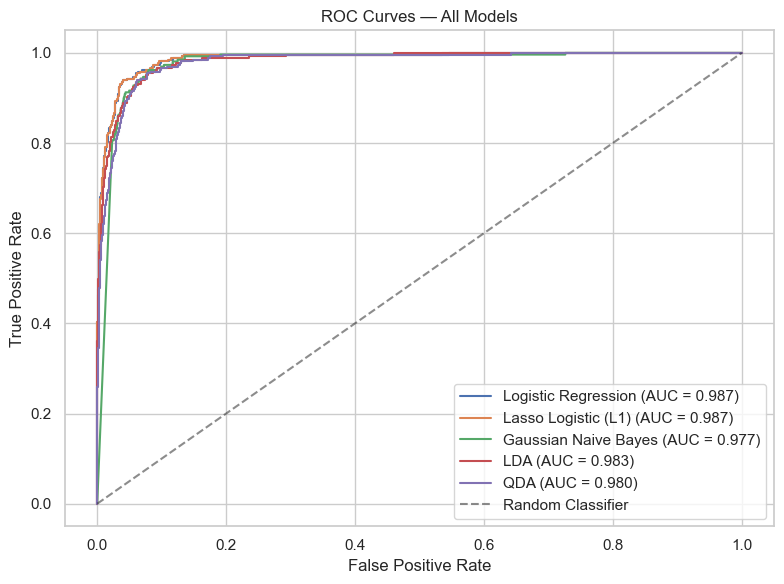

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in fitted_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Confusion Matrices

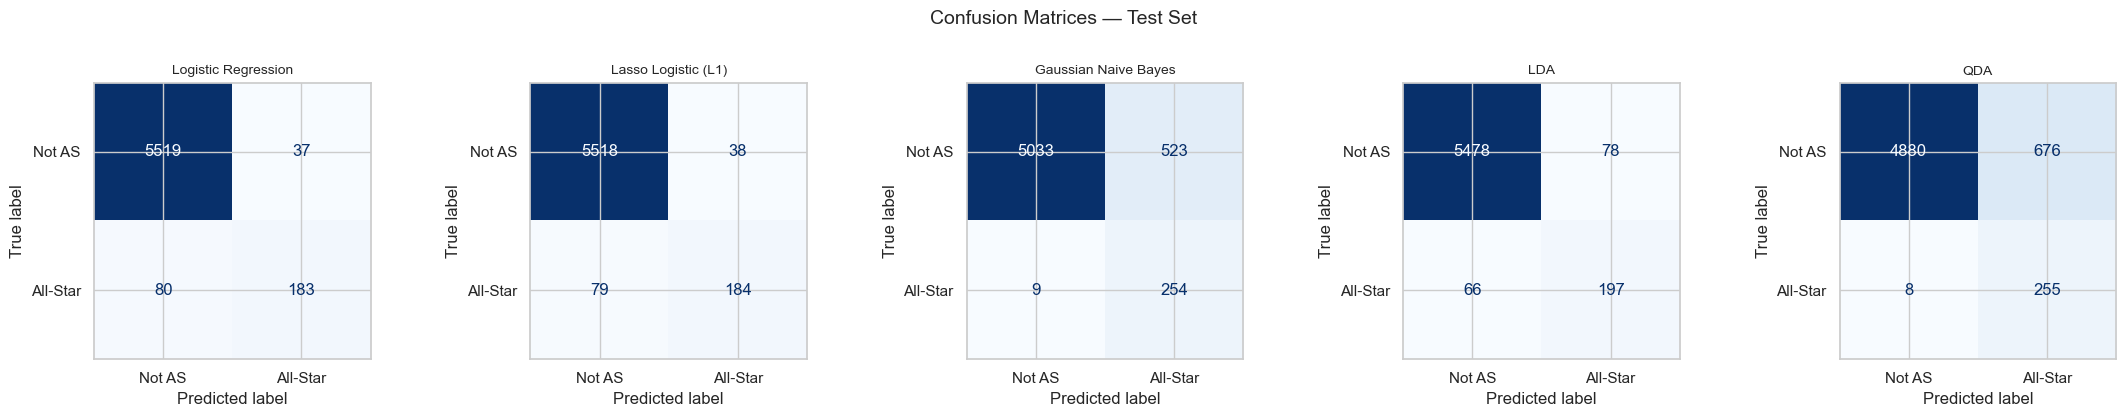

In [24]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not AS", "All-Star"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=10)

plt.suptitle("Confusion Matrices — Test Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Feature Importance (Lasso Logistic Regression)

The L1-regularized logistic regression drives irrelevant coefficients to zero, giving us a natural ranking of the most important features for predicting All-Star selection.

In [25]:
lasso_model = fitted_models["Lasso Logistic (L1)"]
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": lasso_model.coef_[0]
}).assign(AbsCoef=lambda d: d["Coefficient"].abs()).sort_values("AbsCoef", ascending=False)

print("===== Top 15 Features by |Coefficient| (Lasso Logistic) =====\n")
print(coef_df.head(15)[["Feature", "Coefficient"]].to_string(index=False))

===== Top 15 Features by |Coefficient| (Lasso Logistic) =====

      Feature  Coefficient
  mp_per_game     1.000520
 x2p_per_game     0.990275
 x3p_per_game     0.936018
  usg_percent     0.875490
          dws     0.735518
  tov_percent     0.692223
 ast_per_game     0.690499
        ws_48     0.670209
       age_pg     0.600730
           mp    -0.552096
  x2p_percent    -0.521037
x3pa_per_game    -0.506642
  ast_percent    -0.486917
   fg_percent     0.434419
  drb_percent    -0.433597


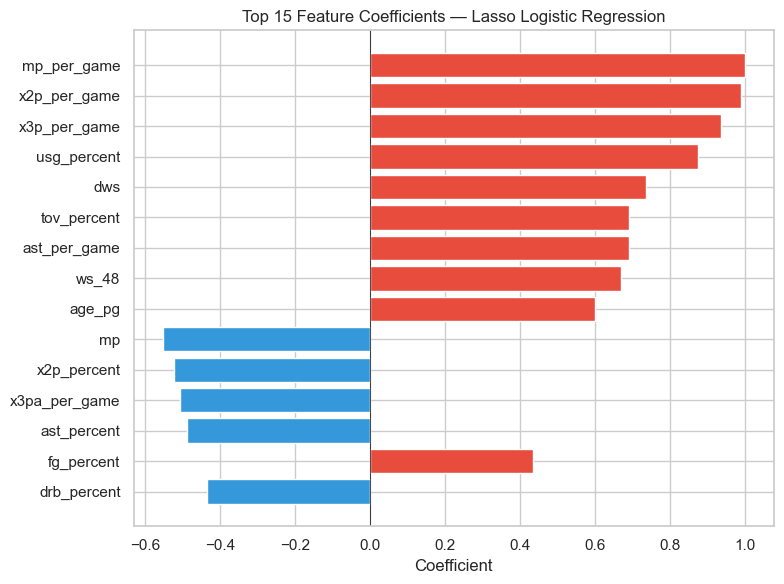

In [26]:
top_n = 15
top = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#e74c3c" if c > 0 else "#3498db" for c in top["Coefficient"]]
ax.barh(top["Feature"][::-1], top["Coefficient"][::-1], color=colors[::-1])
ax.set_xlabel("Coefficient")
ax.set_title("Top 15 Feature Coefficients — Lasso Logistic Regression")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

### Detailed Classification Report (Best Model)

In [27]:
best_name = test_df["AUC-ROC"].idxmax()
best_model = fitted_models[best_name]
print(f"Best model by AUC-ROC: {best_name}\n")
y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best, target_names=["Not All-Star", "All-Star"]))

Best model by AUC-ROC: Lasso Logistic (L1)

              precision    recall  f1-score   support

Not All-Star       0.99      0.99      0.99      5556
    All-Star       0.83      0.70      0.76       263

    accuracy                           0.98      5819
   macro avg       0.91      0.85      0.87      5819
weighted avg       0.98      0.98      0.98      5819

